<a href="https://colab.research.google.com/github/ikeyareinaldosae/ITC501---Artificial-Intelligence-Applications/blob/main/Week_9_Optimising_AI_Models_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Week 9 Lab - Optimising AI Models**

## **Introduction**

During this lab, we are going to be utilising [SciKit-Learn](https://scikit-learn.org/stable/) to train our own Linear Regression algorithm. We will intentionally _reuse_ the `RandomForestRegressor()` algorithm which we implemented in week 5, and aim to improve the performance through Hyperparameter tuning. We will do this in two sections: manually and through an auto-hyperparameter-tuning library.

By the end of this lab, you will be able to:

- Import the relevant classes and data from SciKit-Learn
- Build a baseline model using the standard hyperparameters, and measure it's performance.
- Implement a manual training loop to re-train the model over a number of options over multiple hyperparameter options, and measure it's performance for each
- Implement an automated hyperparameter trianing library for finding the best values for certain parameters

In this lab, we will be working only on data for supervised learning:

1. [California Housing dataset](https://scikit-learn.org/stable/datasets/real_world.html#california-housing-dataset) using the [`fetch_california_housing()`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html) function.

We again chose this data set to maintain some consistency with the previous week's Lab, so you can see how the performance may be affected by some of these more advanced algorithms.

Let's get started!

## **Preparation**

### Imports

First thing that we want to do is import all the relevant classes and objects that we will be using in our analysis. It is typical that these `import` statements are found at the _top_ of the notebook, and not scattered throughout.

In [1]:
# Python builtins
from pprint import pprint

# Import typical python objects
import numpy as np
import pandas as pd

# Import sklearn objects
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_squared_error,
    PredictionErrorDisplay,
)

### California Housing dataset

In [2]:
data = fetch_california_housing()

#### Inspect

You should already be familiar with the details of this data set now. Here, we will just show what the data looks like. For more details, please review the lab from week 5.

In [3]:
# Check the feature data
display(
    pd.DataFrame(
        data=np.column_stack([data.data, data.target]),
        columns=data.feature_names + data.target_names,
    )
)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


This is the point where we would implement any data cleaning steps that we may want to do. Like, for example, normalisation, feature engineering, etc. This is also where we would do our typical exploratory data analysis (EDA) to ensure that we thoroughly understand the data that we are dealing with here.

#### Split data

Within the [`train_test_split()`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) function, we can parse in both the `data.data` _and_ the `data.target` objects, and the function will split them both equally. We've defined that the `test_size` should be $20\%$ of the data, which means we are reserving $80\%$ for training. And finally, for reproducability, we define a `random_state` using the value `42`, so that anyone else who runs this same function using the same value will get the same result.

In [4]:
# Split the data into training and testing sets
(
    X_train,
    X_test,
    y_train,
    y_test,
) = train_test_split(
    data.data, data.target, test_size=0.2, random_state=42
)

We can easily validate that the data has been distributed equally by checking the [`.size`](https://numpy.org/doc/stable/reference/generated/numpy.ndarray.size.html) of each object.

In [5]:
# Check dimensions of all objects using Python's `eval()` function
for obj in [
    "X_train",
    "X_test",
    "y_train",
    "y_test",
]:
    print(f"{obj}: {eval(obj).shape}")

X_train: (16512, 8)
X_test: (4128, 8)
y_train: (16512,)
y_test: (4128,)


## **Part 1: Baseline Model Performance (standard model parameters)**

We are going to use the [`RandomForestRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html) class. In this baseline performance, we will just use the standard parameters

##### **Task - Instantiate the `RandomForestRegressor()` class**

In [8]:
# !TASK!
# Instantiate the `RandomForestRegressor()` class
rf_model = RandomForestRegressor(random_state=42)

Train the algorithm using the `.fit()` methos, parse'ing in the `X_train` and `y_train` datasets

##### **Task - Train the RandomForestRegressor algorithm**

In [9]:
# !TASK!
# Train the RandomForestRegressor algorithm
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

Create a prediction using the `.predict()` method, parse'ing in the `X_test` dataset.

##### **Task - Predict on the X_test data**

In [10]:
# !TASK!
# Predict on the X_test data
pred_forest = rf_model.predict(X_test)

Let's check the performance.

In [11]:
# Quick check on the predicted values
display(
    pd.DataFrame(
        zip(y_test, pred_forest),
        columns=["actual", "predicted"],
    )
)

,actual,predicted
0,0.47700,0.509500
1,0.45800,0.741610
2,5.00001,4.923257
3,2.18600,2.529610
4,2.78000,2.273690
...,...,...
4123,2.63300,2.267210
4124,2.66800,1.993650
4125,5.00001,4.758219
4126,0.72300,0.714090


In [12]:
# Measure the performance of the model
mse_forest = mean_squared_error(y_test, pred_forest)
print(f"Mean Squared Error: {mse_forest}")

Mean Squared Error: 0.2553684927247781


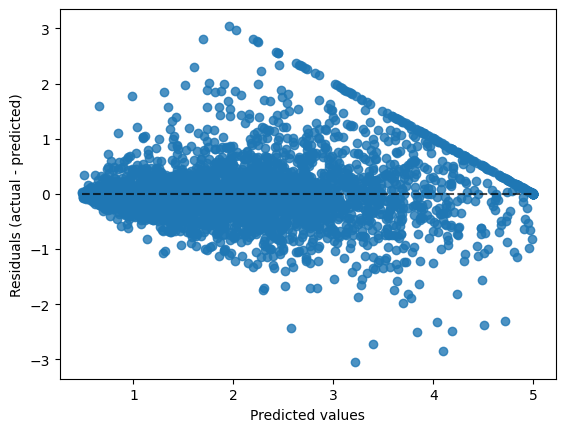

In [13]:
# View the error plot
error_plot_forest = PredictionErrorDisplay(
    y_true=y_test, y_pred=pred_forest
)
_ = error_plot_forest.plot()

There we go. $0.255$ is our baseline. Let's see if we can reach a better performance by testing different hyperparameters.

## **Part 2: Manual Hyperparameter Tuning**

The first thing to note about hyperparameter tuning is the names of the parametes which you have to work with, and the optional values that they can contain.

Here, let's inspect the docs for the [`RandomForestRegressor()`]() class:

```python
sklearn.ensemble.RandomForestRegressor(
    n_estimators=100,               #int, default=100
    criterion='squared_error',      #str, one of: [“squared_error”, “absolute_error”, “friedman_mse”, “poisson”], default=”squared_error”
    max_depth=None,                 #int, default=None
    min_samples_split=2,            #int or float, default=2
    min_samples_leaf=1,             #int or float, default=1
    min_weight_fraction_leaf=0.0,   #float, default=0.0
    max_features=1.0,               #int or float, one of: [“sqrt”, “log2”, None], default=1.0
    max_leaf_nodes=None,            #int, default=None
    min_impurity_decrease=0.0,      #float, default=0.0
    bootstrap=True,                 #bool, default=True
    oob_score=False,                #bool or callable, default=False
    n_jobs=None,                    #int, default=None
    random_state=None,              #int, RandomState instance or None, default=None
    verbose=0,                      #int, default=0
    warm_start=False,               #bool, default=False
    ccp_alpha=0.0,                  #non-negative float, default=0.0
    max_samples=None,               #int or float, default=None
)
```

Inspecting the details of this class, it's clear that not all of them are parameters that feed into the algorithm, but more 'performance' parameters for my computer.

So therefore, here's the list of parameters that we should train for:

```python
"n_estimators"
"max_depth"
"min_samples_split"
"min_samples_leaf"
"min_weight_fraction_leaf"
"max_features"
"max_leaf_nodes"
"min_impurity_decrease"
"max_samples"
```

So now, in the next step, let's set up a training grid of all of the possible training values that we'd like to test for.

For each of the above listed parameters, create a `list` which contains all the values that you want to test for.

The actual values you choose are up to you.

**Warning:** Keep the number of values per parameter _low_ ! Otherwise your grid search will expand out to millions of iterations.

##### **Task - Create alist for each value you want to test for**

In [33]:
# !TASK!
# Create a list for each value you want to test for

n_estimators = 33,
max_depth = None,
min_samples_split = 2,
min_samples_leaf = 1,
min_weight_fraction_leaf = 0.0,
max_features = 1.0,
max_leaf_nodes = None,
min_impurity_decrease = 0.0,
max_samples = None,

Now that we've create a list of all our values, let's wrap it together in to a big training grid.

For this, we will use the `product()` function from the `itertools` library, and parse that in to `pandas` DataFrame so we can iterate over each row.

In [34]:
from itertools import product

grid = {
    "n_estimators": n_estimators,
    "max_depth": max_depth,
    "min_samples_split": min_samples_split,
    "min_samples_leaf": min_samples_leaf,
    "min_weight_fraction_leaf": min_weight_fraction_leaf,
    "max_features": max_features,
    "max_leaf_nodes": max_leaf_nodes,
    "min_impurity_decrease": min_impurity_decrease,
    "max_samples": max_samples,
}

grid_table = pd.DataFrame(
    data=[row for row in product(*grid.values())],
    columns=grid.keys(),
)

display(grid_table)

,n_estimators,max_depth,min_samples_split,min_samples_leaf,min_weight_fraction_leaf,max_features,max_leaf_nodes,min_impurity_decrease,max_samples
0,33,None,2,1,0.0,1.0,None,0.0,None


Again, be careful about the amount of values you choose for your estimators. This brute-force approach can take some time to train; especially if you have millions and millions of models to try for.

Next, we want to iterate over every single row, training a _new_ model for _each_ row, then testing the performance, and saving the result.

In [35]:
grid["mse"] = []

for row in grid_table.itertuples():
    model = RandomForestRegressor(
        n_estimators=row.n_estimators,
        max_depth=row.max_depth,
        min_samples_split=row.min_samples_split,
        min_samples_leaf=row.min_samples_leaf,
        min_weight_fraction_leaf=row.min_weight_fraction_leaf,
        max_features=row.max_features,
        max_leaf_nodes=row.max_leaf_nodes,
        min_impurity_decrease=row.min_impurity_decrease,
        max_samples=row.max_samples,
        random_state=42,
    )
    model.fit(X=X_train, y=y_train)
    pred = model.predict(X=X_test)
    mse = mean_squared_error(y_test, pred)
    grid["mse"].append(mse)

Depending on the power of your computer, this training loop may take longer than an hour...

Now that the training has finished, we can inspect the results. We will add our `mse` values to the `grid_results` table which we created before.

In [36]:
grid_results = pd.DataFrame(
    data=np.column_stack([grid_table.values, grid["mse"]]),
    columns=list(grid_table.columns) + ["mse"],
)
display(grid_results)

,n_estimators,max_depth,min_samples_split,min_samples_leaf,min_weight_fraction_leaf,max_features,max_leaf_nodes,min_impurity_decrease,max_samples,mse
0,33,None,2,1,0.0,1.0,None,0.0,None,0.260069


And next, we can inspect the best values

In [37]:
best_params = (
    grid_results.query("mse==@grid_results.mse.min()")
    .head(1)
    .to_dict(orient="list")
)
pprint(best_params)

{'max_depth': [None],
 'max_features': [1.0],
 'max_leaf_nodes': [None],
 'max_samples': [None],
 'min_impurity_decrease': [0.0],
 'min_samples_leaf': [1],
 'min_samples_split': [2],
 'min_weight_fraction_leaf': [0.0],
 'mse': [0.2600685857024313],
 'n_estimators': [33]}


Because we will use these params to retrain a single model in the next step, we just need to modify this dictionary a little bit by deleting the `mse` key, and convert each of the values from a `list` to a `float` value.

In [38]:
params = {
    key: val[0]
    for key, val in best_params.items()
    if not key in ["mse"]
}
pprint(params)

{'max_depth': None,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 33}


The last step here is to retrain a single model using the new parameters which we have found.

In [39]:
model = RandomForestRegressor(**params, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse_manual = mean_squared_error(y_test, y_pred)
print(mse_manual)

0.2600685857024313


Do note that this process seems logical. However, it is not computationally efficient or 'smart' in it's selection of which parameters to test for. In order to improve this, we can instead use some intelligent processes from the [Hyperopt](https://hyperopt.github.io/hyperopt/) library.

## **Part 3: Automated Hyperparameter Tuning**

**Hyperopt** is an open source hyperparameter tuning library that uses a [Bayesian](https://towardsdatascience.com/bayesian-regression-from-scratch-a1fe19ff64c) approach to find the best values for the hyperparameters. We are not going to dive into the theoretical detials of how this Bayesian approach works, mainly because it would require another entire article to fully explain ! However, the interested readers can view the documentation [here](http://hyperopt.github.io/hyperopt/) and there are also several research papers published on the topic if thats more your speed.

You can also read a really good tutorial on using Hyperopt here: [Hyperopt Tutorial: Optimise Your Hyperparameter Tuning](https://towardsdatascience.com/optimise-your-hyperparameter-tuning-with-hyperopt-861573239eb5).

### Setting Up Hyperopt

To use Hyperopt we need to specify four key things for our model:

- **Objective Function**: This should return the value we want to minimise during the computation. In our case, it's the `mean_squared_error` function.
- **Search Space**: This defines the range of values a given hyperparameter can take. This can be integers, floats or strings as we shall see later in the article.
- **Tuning Algorithm**: In Hyperopt, there are two main hyperparameter search algorithms: Random Search and Tree of Parzen Estimators (Bayesian). In this example, we will be using the latter as it is known to produce the best results.
- **Evaluations**: This refers to the number of different hyperparameter instances to train the model over. This is recommended to be between 10–30 times the number of hyperparameters defined in the search space to optimise for performance and computation time.

To begin, let's import the required sections from the `hyperopt` library (case sensitive): `hp`, `tpe`, `Trials`, `space_eval`, `STATUS_OK`, `fmin`.

##### **Task - Import hyperopt values**

In [40]:
# !TASK!
# Import hyperopt values
from hyperopt import hp, tpe, Trials, space_eval, STATUS_OK, fmin

Our next task is to define an objective function which will be used by Hyperopt to retrain the models and check the performance.

Here, we've already written most of the function for you. You simply need to add the sections for training the model, testing the model, and checking the performance.

##### **Task - Define the function you want to minimise**

In [53]:
# !TASK!
# Define the function we want to minimise
def objective(search_space: dict) -> dict:
    model = RandomForestRegressor(
        **search_space, random_state=42
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    return {"loss": mse, "status": STATUS_OK}

Now that we have established the objective function, we next need to set the search space. This will be used by Hoperopt to know the upper and lower limits of each parameter used for training.

In Hoperopt, the `hp` module provides a number of parameter expressions which can be used by the algorithm. You can read more [here](https://hyperopt.github.io/hyperopt/getting-started/search_spaces/#parameter-expressions). For all the options available by Hyperopt, we are only going to use two:

- `hp.randint()`: Returns a random integer in the range [low, upper).
- `hp.uniform()`: Returns a value uniformly between `low` and `high`.

In the below task, fill in the missing details with values that you want to use for testing.

##### **Task - Define the search space for each parameter**

In [54]:
# !TASK!
# Define the search space for each parameter
n_estimators = hp.randint("n_estimators", 10, 200)
max_depth = hp.randint("max_depth", 1, 30)
min_samples_split = hp.randint("min_samples_split", 2, 20)
min_samples_leaf = hp.randint("min_samples_leaf", 1, 20)
min_weight_fraction_leaf = hp.uniform("min_weight_fraction_leaf", 0.0, 0.5)
max_features = hp.uniform("max_features", 0.1, 1.0)
max_leaf_nodes = hp.randint("max_leaf_nodes", 10, 500)
min_impurity_decrease = hp.uniform("min_impurity_decrease", 0.0, 0.2)
max_samples = hp.uniform("max_samples", 0.5, 1.0)

Now we can compile it together in to a single dictionary object containing our new search space.

In [55]:
# new search space
search_space = {
    "n_estimators": n_estimators,
    "max_depth": max_depth,
    "min_samples_split": min_samples_split,
    "min_samples_leaf": min_samples_leaf,
    "min_weight_fraction_leaf": min_weight_fraction_leaf,
    "max_features": max_features,
    "max_leaf_nodes": max_leaf_nodes,
    "min_impurity_decrease": min_impurity_decrease,
    "max_samples": max_samples,
}

Now that we have both the objective function and the search space, next we need to set which search algorithm that Hyperopt will use to perform the optimisation. Here, we will use the **Tree of Parzen Estimators** (`tpe`), which is how Hyperopt will implement the Baysian optimisation.

In [56]:
# set the hyperparam tuning algorithm
algorithm = tpe.suggest

Finally, we combine this using the `fmin` function. The `fn` function aim is to minimise the function assigned to it, which is the objective that was defined above. Additionally, `max_evals` refers to the number of different hyperparameters we want to test. You can set this to be any number that you would like, however Hyperopt suggest to set it to be at least 10 times the number of parameters which you are testing for.

##### **Task - Implement Hyperopt**

In [57]:
# !TASK!
# implement Hyperopt
best_params = fmin(
    fn=objective,
    space=search_space,
    algo=algorithm,
    max_evals=10,
)

100%|██████████| 10/10 [00:10<00:00,  1.04s/trial, best loss: 0.7199961334240197]


Now that training is completed, we can check which metrics were best for our model:

In [58]:
# Check the best parameters
params = space_eval(search_space, best_params)
pprint(params)

{'max_depth': np.int64(26),
 'max_features': 0.38093608200655915,
 'max_leaf_nodes': np.int64(199),
 'max_samples': 0.5595788000941343,
 'min_impurity_decrease': 0.026681314547797343,
 'min_samples_leaf': np.int64(19),
 'min_samples_split': np.int64(8),
 'min_weight_fraction_leaf': 0.1099445803737863,
 'n_estimators': np.int64(118)}


So, let's retrain a single algorithm with these parameters:

In [59]:
model = RandomForestRegressor(**params, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse_auto = mean_squared_error(y_test, y_pred)
print(mse_auto)

0.7199961334240197


## Comparison

In [60]:
print(f"{mse_forest=}")
print(f"{mse_manual=}")
print(f"{mse_auto=}")

mse_forest=0.2553684927247781
mse_manual=0.2600685857024313
mse_auto=0.7199961334240197


What can we conclude from this analysis?

1. The default parameters on the `RandomForestRegressor` is not bad! But potentially can be improved.
1. The manual training grid options is slow, expensive, inefficient, and uninformed (that is, it does not adjust the parameter options based on the results of the previous model iteration). However it can certainly get good results if we consider a reasonable grid. Perhaps we can construct a grid around the default parameters next time?
1. The automated hyperparameter tuning is quicker, more accurate, and more optimised in selecting the 'direction' for each training iteration. But it is harder to explain sometimes.

# Submission
When you are ready to submit please go to `File` -> `Print` -> `Print PDF` and then upload and submit in the Campus Online.

Please save your file to GitHub via: `File` -> `Save a copy in GitHub`